# Verificación de imágenes del dataset 

10-09-2026
- Luis Pablo López Iracheta

**Objetivo:** comprobar que las imágenes de `data_1/train/images` se pueden extraer (leer del disco) y visualizar correctamente, y que ninguna está corrupta.

In [1]:
# Librerías necesarias
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

random.seed(42)

In [2]:
# Rutas del dataset (este notebook vive en Analysis/, el dataset en data_1/)
BASE_DIR = Path.cwd().parent if Path.cwd().name == "Analysis" else Path.cwd()
TRAIN_IMAGES_DIR = BASE_DIR / "data_1" / "train" / "images"
TRAIN_LABELS_DIR = BASE_DIR / "data_1" / "train" / "labels"

print("Directorio base :", BASE_DIR)
print("Imágenes train  :", TRAIN_IMAGES_DIR)
print("¿Existe la carpeta de imágenes?:", TRAIN_IMAGES_DIR.is_dir())

Directorio base : c:\IBERO\A7Semestre\Integracion_de_aplicaciones\XYRON_VISION
Imágenes train  : c:\IBERO\A7Semestre\Integracion_de_aplicaciones\XYRON_VISION\data_1\train\images
¿Existe la carpeta de imágenes?: True


In [3]:
# 1) Extracción: listar los archivos de imagen disponibles
VALID_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

all_files = sorted(TRAIN_IMAGES_DIR.iterdir())
image_files = [p for p in all_files if p.suffix.lower() in VALID_EXT]
other_files = [p for p in all_files if p.suffix.lower() not in VALID_EXT]

print(f"Total de archivos en la carpeta : {len(all_files)}")
print(f"Archivos de imagen reconocidos  : {len(image_files)}")
print(f"Otros archivos (no imagen)      : {len(other_files)}")
if other_files:
    print("  ->", [p.name for p in other_files[:10]])

print("\nExtensiones encontradas:", sorted({p.suffix.lower() for p in image_files}))
print("\nEjemplos de nombres:")
for p in image_files[:5]:
    print("  -", p.name)

Total de archivos en la carpeta : 834
Archivos de imagen reconocidos  : 834
Otros archivos (no imagen)      : 0

Extensiones encontradas: ['.jpg']

Ejemplos de nombres:
  - 0e538f39-1d30436c-c23_jpg.rf.05ff78024b481ae4fada24ef439ebd97.jpg
  - 0e538f39-1d30436c-c23_jpg.rf.26d4bf7a38b3bf4195696d7d002dfc32.jpg
  - 0e538f39-1d30436c-c23_jpg.rf.3ce38b0e86b3cd83db06acc794de04f0.jpg
  - 0e538f39-1d30436c-c23_jpg.rf.68d881523d9df5f75e91f0d319e2ad5c.jpg
  - 0e538f39-1d30436c-c23_jpg.rf.77546dd3e656d80bb16894a47fb55b27.jpg


In [4]:
# 2) Integridad: abrir cada imagen y verificar que no esté corrupta
corruptas = []
tamaños = []
modos = {}

for p in image_files:
    try:
        with Image.open(p) as img:
            img.verify()  # detecta archivos truncados / corruptos
        with Image.open(p) as img:
            img.load()
            tamaños.append(img.size)
            modos[img.mode] = modos.get(img.mode, 0) + 1
    except (UnidentifiedImageError, OSError, SyntaxError) as e:
        corruptas.append((p.name, repr(e)))

ok = len(image_files) - len(corruptas)
print(f"Imágenes leídas correctamente : {ok} / {len(image_files)}")
print(f"Imágenes corruptas / ilegibles: {len(corruptas)}")
for nombre, err in corruptas[:20]:
    print("  -", nombre, "->", err)

if tamaños:
    anchos = [w for w, h in tamaños]
    altos = [h for w, h in tamaños]
    print(f"\nResolución ancho: min {min(anchos)}, max {max(anchos)} | alto: min {min(altos)}, max {max(altos)}")
    print(f"Modos de color: {modos}")

assert not corruptas, "Hay imágenes que no se pudieron leer (ver lista arriba)."

Imágenes leídas correctamente : 834 / 834
Imágenes corruptas / ilegibles: 0

Resolución ancho: min 640, max 640 | alto: min 640, max 640
Modos de color: {'RGB': 834}


Imagen        : SampleV2_2_mp4-5_jpg.rf.acc6416dfd26963fa5d9f2547a35b4ed.jpg
Tamaño (px)   : (640, 640)
Modo de color : RGB
Peso (bytes)  : 48988


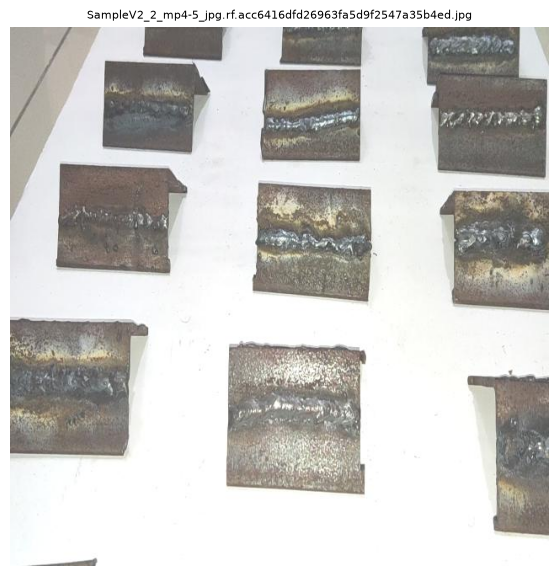

In [5]:
# 3) Visualización: mostrar una imagen individual elegida al azar
muestra = random.choice(image_files)
img = Image.open(muestra)

print("Imagen        :", muestra.name)
print("Tamaño (px)   :", img.size)
print("Modo de color :", img.mode)
print("Peso (bytes)  :", muestra.stat().st_size)

plt.figure(figsize=(7, 7))
plt.imshow(img)
plt.title(muestra.name, fontsize=8)
plt.axis("off")
plt.show()

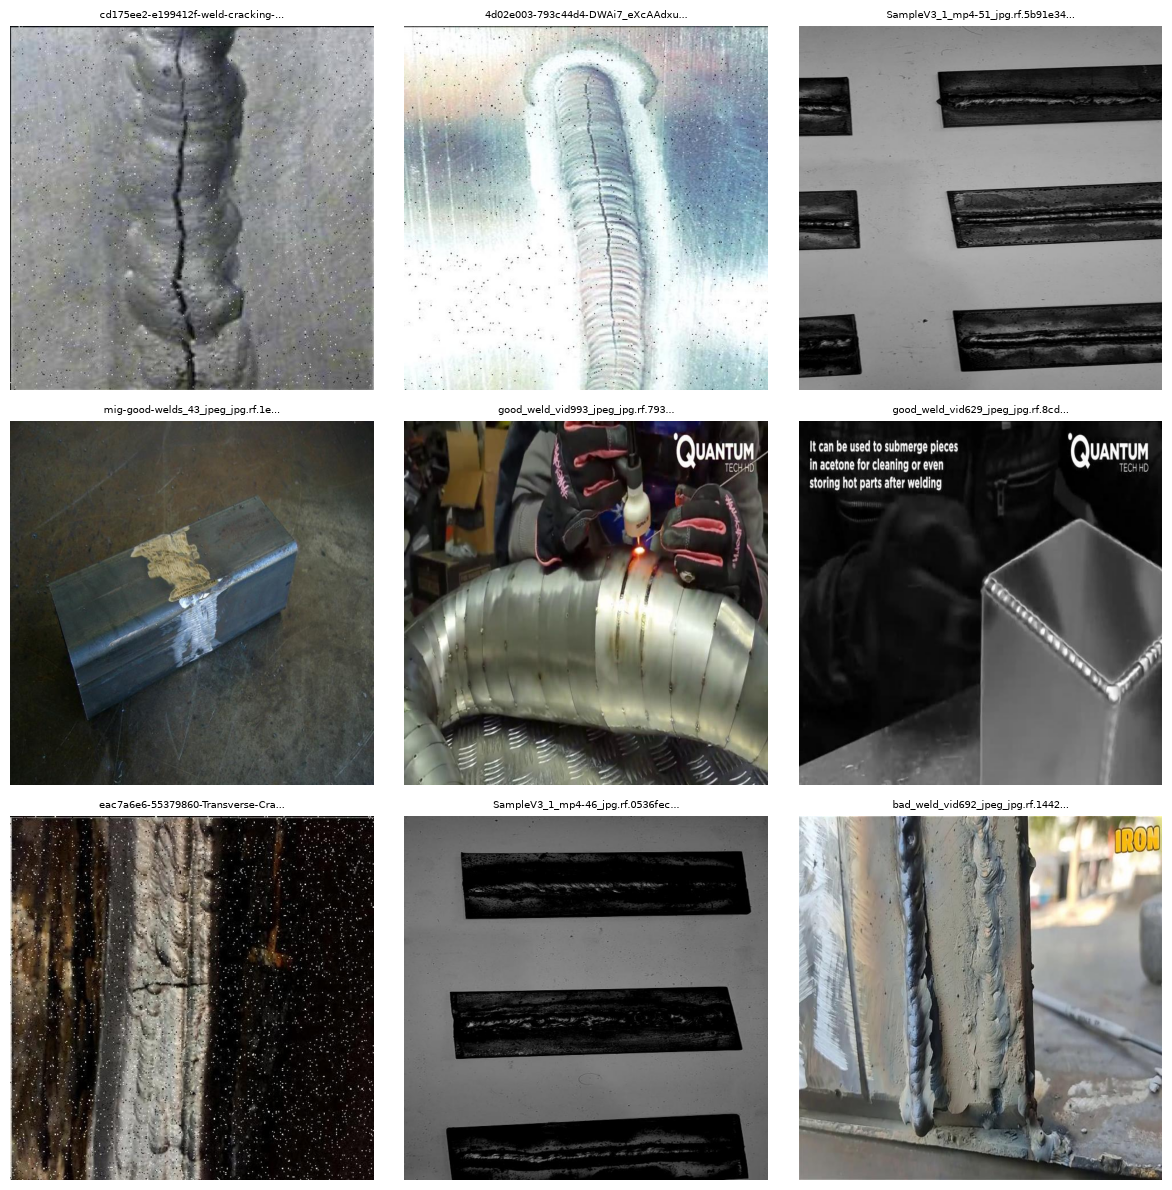

In [6]:
# 4) Visualización: cuadrícula con varias imágenes de muestra
N = 9
muestras = random.sample(image_files, min(N, len(image_files)))

cols = 3
rows = (len(muestras) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))

for ax, ruta in zip(axes.ravel(), muestras):
    ax.imshow(Image.open(ruta))
    ax.set_title(ruta.name[:32] + "...", fontsize=7)
    ax.axis("off")

for ax in axes.ravel()[len(muestras):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
# 5) (Opcional) Comprobar que cada imagen tiene su archivo de anotación .txt
clases = ['Bad Weld', 'Good Weld', 'Defect']  # data_1/data.yaml

sin_label = []
for p in image_files:
    label = TRAIN_LABELS_DIR / (p.stem + ".txt")
    if not label.is_file():
        sin_label.append(p.name)

print(f"Imágenes con etiqueta : {len(image_files) - len(sin_label)} / {len(image_files)}")
print(f"Imágenes sin etiqueta : {len(sin_label)}")
for n in sin_label[:20]:
    print("  -", n)

Imágenes con etiqueta : 834 / 834
Imágenes sin etiqueta : 0


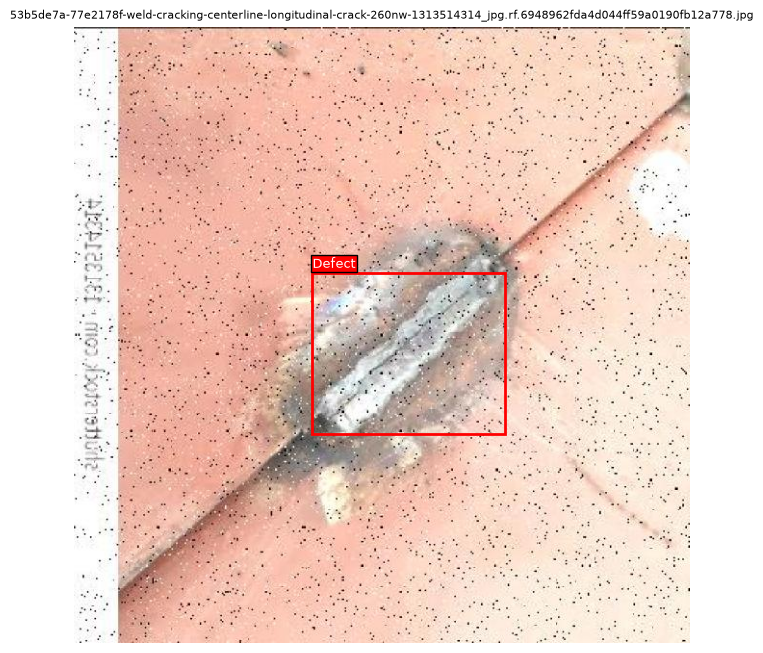

In [15]:
# 6) (Opcional) Mostrar una imagen con sus cajas de anotación (formato YOLO)
import matplotlib.patches as patches

muestra = random.choice(image_files)
img = Image.open(muestra)
W, H = img.size
label_path = TRAIN_LABELS_DIR / (muestra.stem + ".txt")

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)
ax.set_title(muestra.name, fontsize=8)
ax.axis("off")

if label_path.is_file():
    for linea in label_path.read_text().strip().splitlines():
        cid, xc, yc, bw, bh = map(float, linea.split())
        x = (xc - bw / 2) * W
        y = (yc - bh / 2) * H
        ax.add_patch(patches.Rectangle((x, y), bw * W, bh * H, linewidth=2, edgecolor="red", facecolor="none"))
        ax.text(x, y - 5, clases[int(cid)], color="white", fontsize=9,bbox=dict(facecolor="red", pad=1))
else:
    print("Esta imagen no tiene archivo de anotación.")

plt.show()

## Conclusión

Si todas las celdas anteriores se ejecutaron sin errores (los `assert` no fallaron y las imágenes se muestran), queda verificado que:

1. Las imágenes de `data_1/train/images` se pueden **extraer** (leer) desde disco.
2. Ninguna imagen está **corrupta** ni truncada.
3. Las imágenes se pueden **visualizar** correctamente.